In [71]:
from dataclasses import dataclass
import numpy as np
import copy
import nn
from matplotlib import pyplot as plt
import logging

logging.basicConfig(level=logging.INFO, format="%(message)s")
logger = logging.getLogger(__name__)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
n = 10_000
theta = 6 * np.pi * np.random.random(n).reshape((n, 1))
r = 6 * np.pi * np.random.random(n).reshape((n, 1))
y = np.abs((r - theta) % (2 * np.pi)).flatten() < np.pi
X = r * np.concatenate([np.cos(theta), np.sin(theta)], axis=1)

In [7]:
X

array([[ 1.89391569, -6.47648141],
       [ 0.08620258,  6.75653721],
       [ 5.19504094, -3.14662795],
       ...,
       [-3.15938847,  0.78273457],
       [-6.0118973 ,  0.10162051],
       [ 6.32829886, -0.29980362]], shape=(10000, 2))

In [85]:
input_layer_size = 2
hidden_layer_size = 3

l1 = nn.Linear(
    np.random.normal(size=(hidden_layer_size, input_layer_size))
    * 2
    / np.sqrt(input_layer_size)
)
act1 = nn.Max0()
l2 = nn.Linear(
    2
    / np.sqrt(hidden_layer_size)
    * np.random.normal(size=(hidden_layer_size, hidden_layer_size))
)
act2 = nn.Max0()
l3 = nn.Linear(
    1 / np.sqrt(hidden_layer_size) * np.random.normal(size=(1, hidden_layer_size))
)
act3 = nn.MapTo01()

layers = [l1, act1, l2, act2, l3, act3]
neural_network = nn.NN(layers)

In [ ]:
logger.setLevel(logging.ERROR)


def run_test(num_points, num_iterations):
    random_sample = np.random.choice(len(X), size=num_points, replace=False)

    weight_histories = [[] for l in layers]
    inputs = [[] for l in layers]
    gradients = [[] for l in layers]
    losses_by_iter = []

    for training_iteration in range(num_iterations):
        total_loss = 0
        for i in random_sample:
            loss_function = nn.SquaredErrorLoss()
            output = neural_network.run(X[i, :])
            logger.debug(f"output: {output}")
            loss = loss_function.get_loss(output, y[i])
            total_loss += loss
            logger.debug(f"loss: {loss}")
            output_gradient = loss_function.output_gradient(output, y[i])
            logger.debug(f"output_gradient: {output_gradient}")
            neural_network.update(output_gradient, learning_rate=0.1, regularization=0)
            for k, l in enumerate(neural_network.layers):
                weight_histories[k].append(copy.deepcopy(l.weights))
                inputs[k].append(copy.deepcopy(l.previous_inputs))
                gradients[k].append(copy.deepcopy(l.output_gradient))

        losses_by_iter.append(total_loss / num_points)
        logger.info(
            f"--------------------training iteration: {training_iteration}---------------------"
        )

    return {
        "average_losses": losses_by_iter,
        "weight_histories_by_layer": [
            np.concat([m[:, :, None] for m in weight_history], axis=2)
            for weight_history in [
                weight_histories[0],
                weight_histories[2],
                weight_histories[4],
            ]
        ],
        "inputs_by_layer": [
            np.concat([g[:, None] for g in layer_inputs], axis=1)
            for layer_inputs in inputs
        ],
        "gradients_by_layer": [
            np.concat([g[:, None] for g in layer_gradients], axis=1)
            for layer_gradients in gradients
        ],
    }
    #    neural_network.debug_print()

In [120]:
test_result = run_test(20, 100)

In [121]:
test_result["inputs_by_layer"][0].shape

(2, 2000)

In [ ]:
test_result["inputs_by_layer"][0].shape

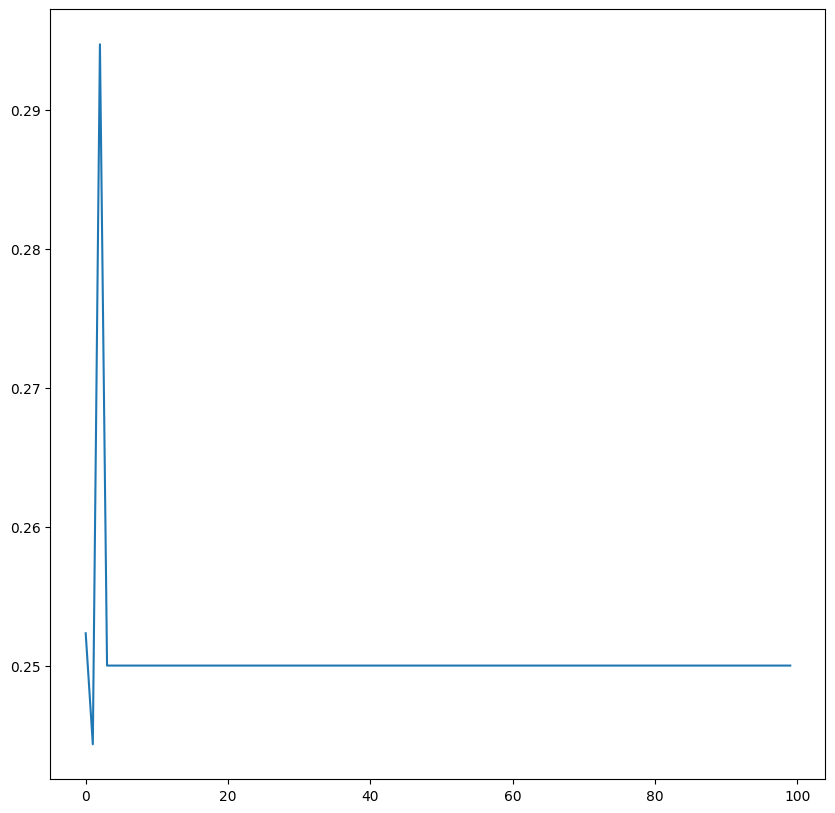

In [111]:
plt.plot(test_result["average_losses"])

In [112]:
test_result["gradients_by_layer"]

[[array([-0.        , -0.        ,  0.01400124]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.01326128]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.       ,  0.       , -0.0449543]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.03386851, -0.01032651]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.06735915]),
  array([-0.        , -0.        ,  0.00453226]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.00488046]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.08896485]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
  array([ 0.        ,  0.        , -0.01871791]),
  array([0., 0., 0.]),
  array([0., 0., 0.]),
 

In [ ]:
np.concat([m[:, :, None] for m in weight_histories[0]], axis=2).reshape((6, 10))

array([[-0.24227568, -0.24227326, -0.24227084, -0.24226842, -0.24226599,
        -0.24226357, -0.24226115, -0.24225873, -0.2422563 , -0.24225388],
       [-0.07287887, -0.07287814, -0.07287742, -0.07287669, -0.07287596,
        -0.07287523, -0.0728745 , -0.07287377, -0.07287304, -0.07287231],
       [-0.51972362, -0.51971842, -0.51971322, -0.51970802, -0.51970283,
        -0.51969763, -0.51969243, -0.51968724, -0.51968204, -0.51967684],
       [ 0.94780767,  0.94779819,  0.94778871,  0.94777923,  0.94776976,
         0.94776028,  0.9477508 ,  0.94774132,  0.94773185,  0.94772237],
       [-1.03215919, -1.03214887, -1.03213855, -1.03212822, -1.0321179 ,
        -1.03210758, -1.03209726, -1.03208694, -1.03207662, -1.0320663 ],
       [-0.23251919, -0.23251686, -0.23251454, -0.23251221, -0.23250989,
        -0.23250756, -0.23250524, -0.23250291, -0.23250059, -0.23249826]])

In [ ]:
np.concat([m[:, :, None] for m in weight_histories[1]], axis=2).reshape((6, 10))

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

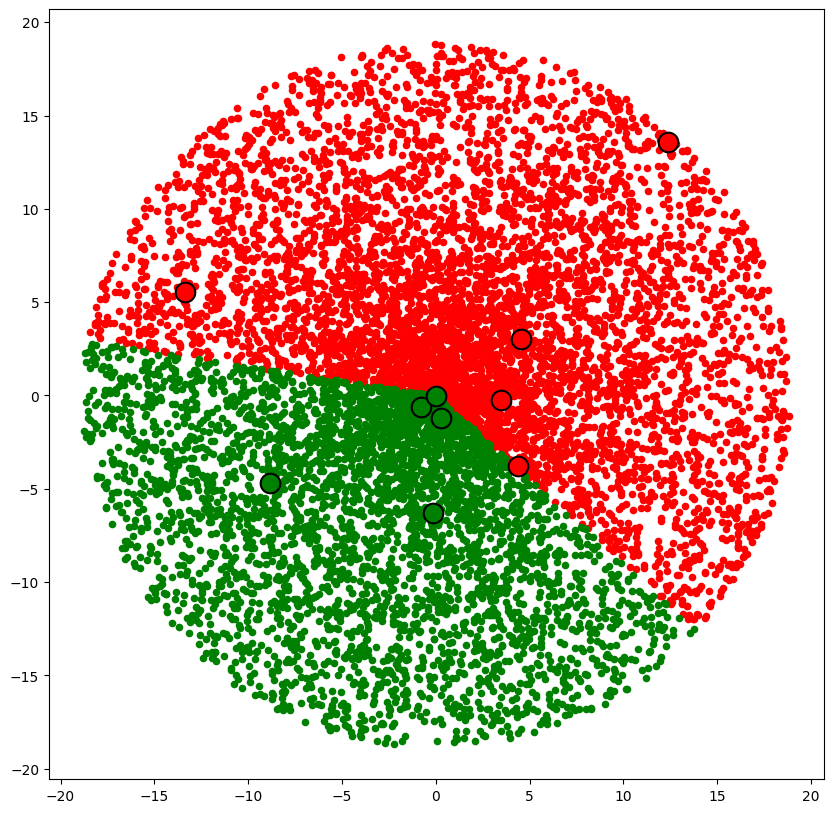

In [91]:
all_points = X
all_predictions = np.array([neural_network.run(x) for x in all_points]).flatten() > 0.5

plt.rcParams["figure.figsize"] = (10, 10)

plt.scatter(X[~all_predictions, 0], X[~all_predictions, 1], color="r", s=20)
plt.scatter(X[all_predictions, 0], X[all_predictions, 1], color="g", s=20)


sample_points = np.array([X[i, :] for i in random_sample])
sample_predictions = (
    np.array([neural_network.run(x) for x in sample_points]).flatten() > 0.5
)
plt.scatter(
    sample_points[~sample_predictions, 0],
    sample_points[~sample_predictions, 1],
    color="r",
    s=200,
    edgecolors="black",
    linewidths=1.5,
)
plt.scatter(
    sample_points[sample_predictions, 0],
    sample_points[sample_predictions, 1],
    color="g",
    s=200,
    edgecolors="black",
    linewidths=1.5,
)

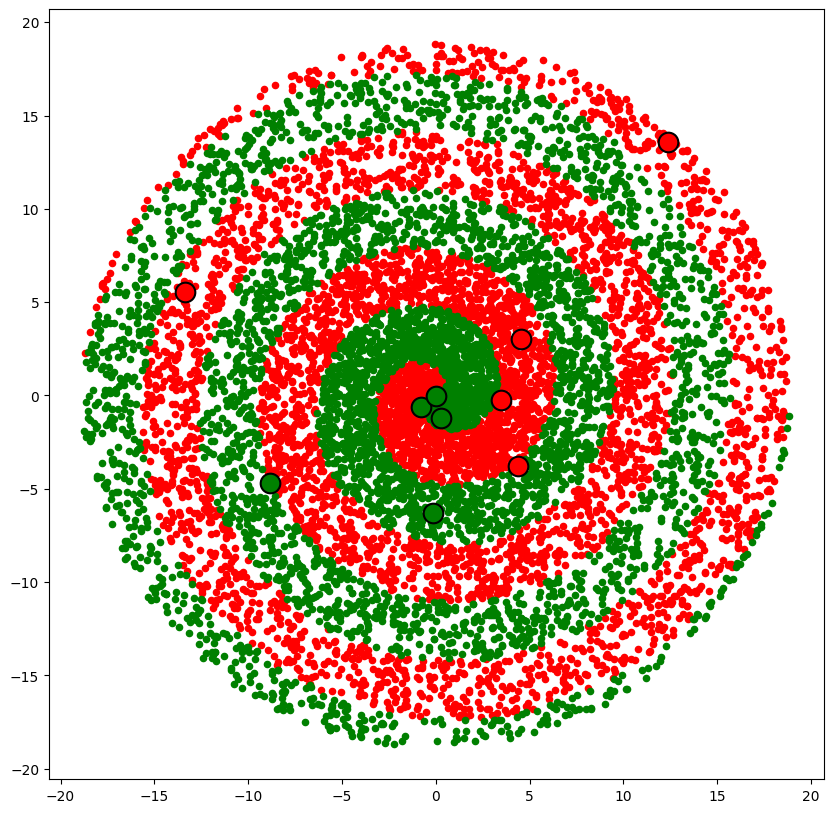

In [92]:
sample_points = np.array([X[i, :] for i in random_sample])
sample_predictions = (
    np.array([neural_network.run(x) for x in sample_points]).flatten() > 0.5
)

plt.rcParams["figure.figsize"] = (10, 10)

plt.scatter(X[~y, 0], X[~y, 1], color="r", s=20)
plt.scatter(X[y, 0], X[y, 1], color="g", s=20)

plt.scatter(
    sample_points[~sample_predictions, 0],
    sample_points[~sample_predictions, 1],
    color="r",
    s=200,
    edgecolors="black",
    linewidths=1.5,
)
plt.scatter(
    sample_points[sample_predictions, 0],
    sample_points[sample_predictions, 1],
    color="g",
    s=200,
    edgecolors="black",
    linewidths=1.5,
)

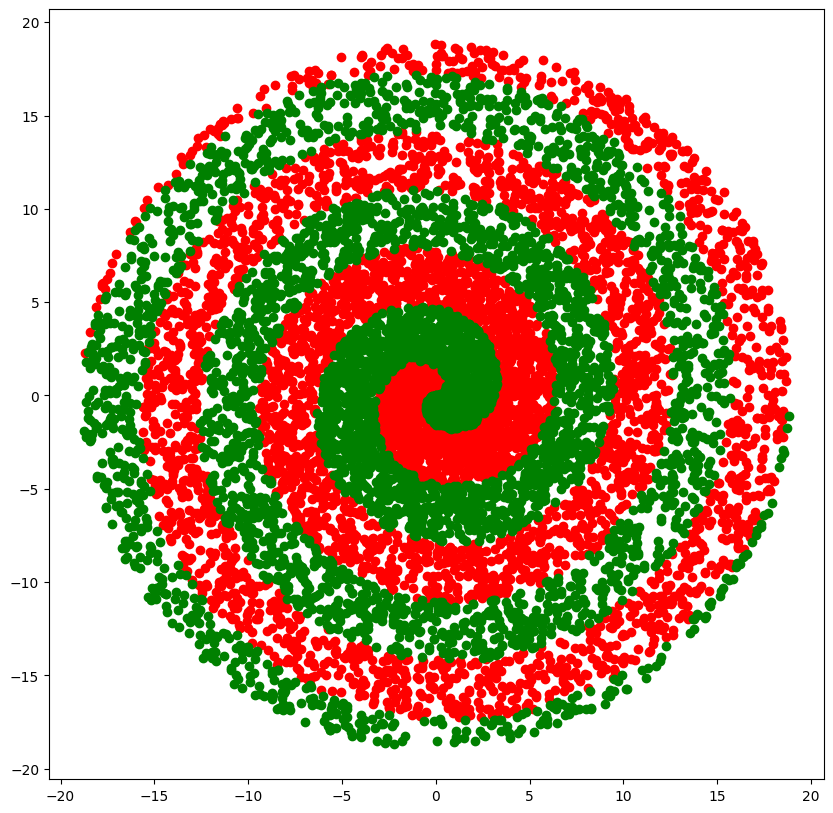

In [12]:
plt.rcParams["figure.figsize"] = (10, 10)
plt.scatter(X[~y, 0], X[~y, 1], color="r")
plt.scatter(X[y, 0], X[y, 1], color="g")

In [ ]:
np.arange(6).reshape((3, 2))

array([[0, 1],
       [2, 3],
       [4, 5]])

In [ ]:
np.arange(1, 4).reshape((1, 3)) * (10 * np.arange(1, 3)).reshape((2, 1))

array([[10, 20, 30],
       [20, 40, 60]])